In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
import natural_units as nu
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

In [2]:
log_m_min  = -3
log_m_max  = 1
n_m    = 17   # From 1e-3  to 10 GeV
m_grid      = np.logspace(log_m_min, log_m_max, n_m)
#log cs shift from the balloon line
center_line = np.array([2.15504637e-23, 1.53030461e-23, 1.26359147e-23, 1.61669130e-23,
       2.40008514e-23, 4.03532201e-23, 6.95747264e-23, 1.40957345e-22,
       2.84518575e-22, 5.17381239e-22, 1.08351297e-21, 2.15203017e-21,
       4.12016417e-21, 7.78952222e-21, 1.45615810e-20, 2.70914228e-20,
       4.94000000e-20])
log_cs_min = -3
log_cs_max = 0
n_cs   = 25
cs_grid = np.logspace(log_cs_min, log_cs_max, n_cs)
signal_gird = np.loadtxt('../SHIELDING_RESULT/signal_grid.txt')

In [3]:
mass_index_test = 4
loc_max_signal = np.argmax(signal_gird[:,mass_index_test])
cs_max_signal = center_line[mass_index_test] * cs_grid[n_cs - 1 - loc_max_signal]
print(loc_max_signal)
print(cs_max_signal)

8
2.40008514e-24


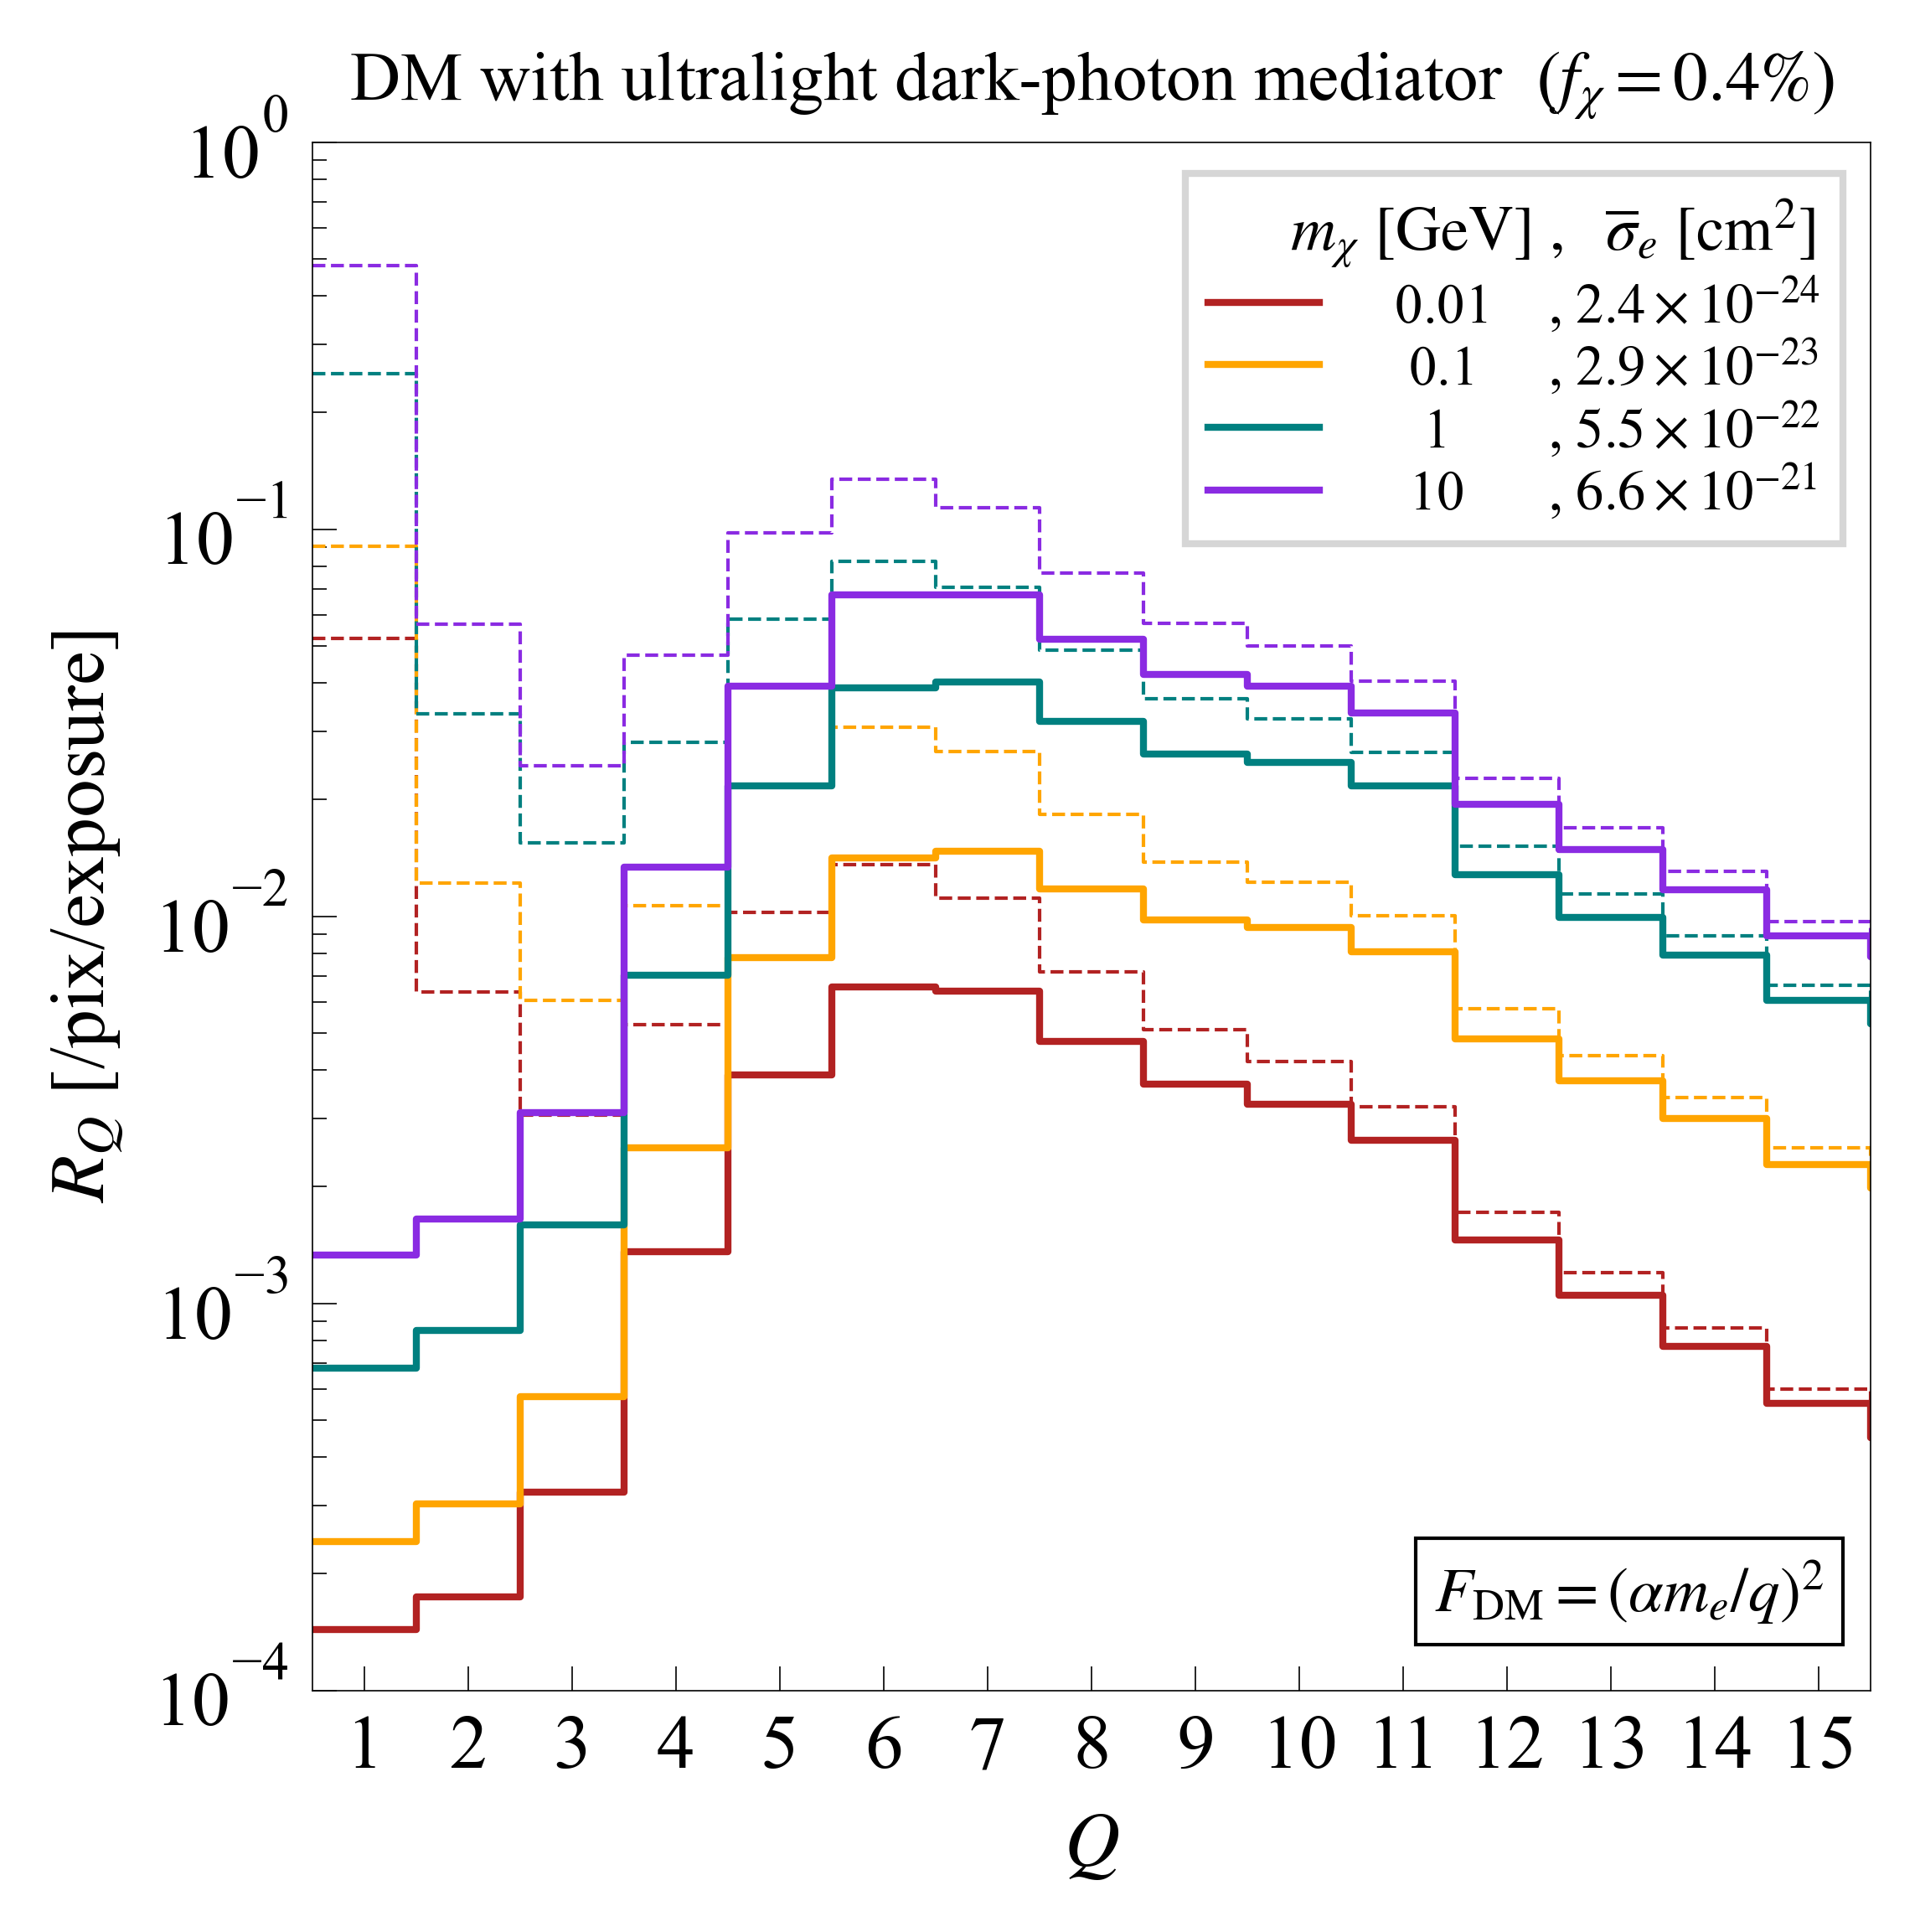

In [36]:
b1 = np.loadtxt('../data/binned_signal_w_shield/binned_signals_mDM=0.01_GeV_sigma=2.40009e-24_cm2.txt')
b2 = np.loadtxt('../data/binned_signal_w_shield/binned_signals_mDM=0.1_GeV_sigma=2.84519e-23_cm2.txt')
b3 = np.loadtxt('../data/binned_signal_w_shield/binned_signals_mDM=1_GeV_sigma=5.49433e-22_cm2.txt')
b4 = np.loadtxt('../data/binned_signal_w_shield/binned_signals_mDM=10_GeV_sigma=6.5876e-21_cm2.txt')
b1_lin = np.loadtxt('../data/binned_signal_w_shield_w_lindhard/binned_signals_mDM=0.01_GeV_sigma=2.40009e-24_cm2.txt')
b2_lin = np.loadtxt('../data/binned_signal_w_shield_w_lindhard/binned_signals_mDM=0.1_GeV_sigma=2.84519e-23_cm2.txt')
b3_lin = np.loadtxt('../data/binned_signal_w_shield_w_lindhard/binned_signals_mDM=1_GeV_sigma=5.49433e-22_cm2.txt')
b4_lin = np.loadtxt('../data/binned_signal_w_shield_w_lindhard/binned_signals_mDM=10_GeV_sigma=6.5876e-21_cm2.txt')
exposure = 3574.278 * 244 / 245
#b1 = b1 / exposure
#b2 = b2 / exposure
#b3 = b3 / exposure
#b4 = b4 / exposure
b1_lin = b1_lin # / exposure
b2_lin = b2_lin # / exposure
b3_lin = b3_lin # / exposure
b4_lin = b4_lin # / exposure
N_bin = 30
bins = np.arange(0.5,N_bin+0.5,1)
fig, ax = plt.subplots(figsize=(4, 4),dpi = 600)
fontsize = 11
ax.semilogy(bins, b1, drawstyle='steps-post',color='firebrick',linestyle='--', linewidth = 0.5)
ax.semilogy(bins, b2, drawstyle='steps-post',color='orange',linestyle='--', linewidth = 0.5)
ax.semilogy(bins, b3, drawstyle='steps-post',color='teal',linestyle='--', linewidth = 0.5)
ax.semilogy(bins, b4, drawstyle='steps-post',color='blueviolet',linestyle='--', linewidth = 0.5)
ax.semilogy(bins, b1_lin, drawstyle='steps-post', linewidth = 1,color='firebrick')
ax.semilogy(bins, b2_lin, drawstyle='steps-post', linewidth = 1,color='orange')
ax.semilogy(bins, b3_lin, drawstyle='steps-post', linewidth = 1,color='teal')
ax.semilogy(bins, b4_lin, drawstyle='steps-post', linewidth = 1,color='blueviolet')

ax.set_title('DM with ultralight dark-photon mediator  ' + r'($f_{\chi}=0.4\%$)', fontsize=fontsize-1)
ax.set_xlabel(r'$Q$', fontsize=fontsize, color='black')  # 设置 x 轴标签
ax.set_ylabel(r'$R_Q~$[/pix/exposure]', fontsize=fontsize, color='black')  # 设置 y 轴标签
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.tick_params(axis="both", direction="in", which = 'major', top=False, right=False, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=False, right=False, width = 0.2)
ax.tick_params(labeltop=False, labelright=False)
ax.tick_params(axis='both', labelsize=fontsize)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
legend_elements = [
    Line2D([0], [0], color='firebrick', linestyle='-', linewidth = 1, label=r'   0.01    ,$~2.4\times10^{-24}$'),
    Line2D([0], [0], color='orange', linestyle='-', linewidth = 1, label=r'    0.1     ,$~2.9\times10^{-23}$'),
    Line2D([0], [0], color='teal', linestyle='-', linewidth = 1, label=r'     1       ,$~5.5\times10^{-22}$'),
    Line2D([0], [0], color='blueviolet', linestyle='-', linewidth = 1, label=r'    10      ,$~6.6\times10^{-21}$')
]
legend = plt.legend(handles=legend_elements, fontsize=8, loc=7, bbox_to_anchor=(1.0, 0.86), handletextpad=0.6, frameon=True, fancybox=False,
                    title=r'     $m_\chi~[\text{GeV}]~,$'+' '+r'$~\overline{\sigma}_e~[\text{cm}^2]$',labelspacing = 0.05)
ax.text(11.3, 1.6e-4, r'$F_{\text{DM}}=(\alpha m_e/q)^2$', fontsize=9, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
legend.get_title().set_fontsize(9)  # 设置标题字体大小
ax.set_ylim(1e-4,1)
ax.set_xlim(0.5, 15.5)
plt.savefig('dm_binned_spectrum.pdf', format="pdf",bbox_inches="tight")
plt.show()

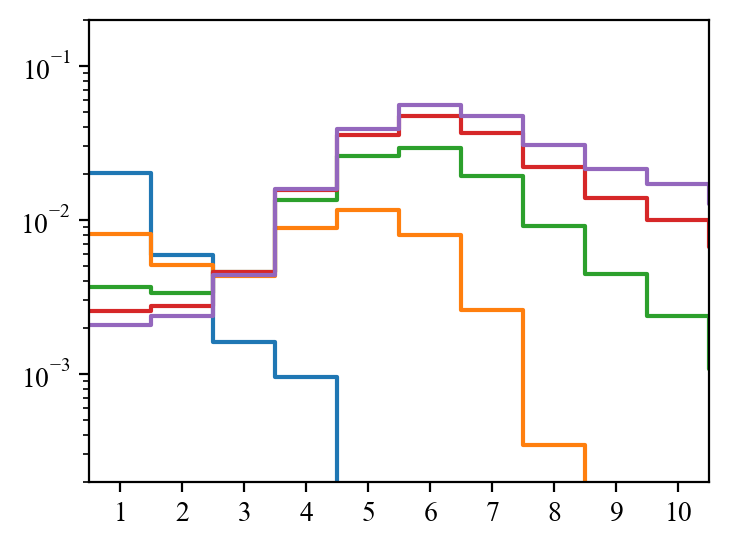

In [14]:
b1 = np.loadtxt('../data/binned_signal_halo_w_lindhard/binned_signals_Halo_0.txt')
b2 = np.loadtxt('../data/binned_signal_halo_w_lindhard/binned_signals_Halo_1.txt')
b3 = np.loadtxt('../data/binned_signal_halo_w_lindhard/binned_signals_Halo_2.txt')
b4 = np.loadtxt('../data/binned_signal_halo_w_lindhard/binned_signals_Halo_3.txt')
b5 = np.loadtxt('../data/binned_signal_halo_w_lindhard/binned_signals_Halo_4.txt')
exposure = 3574.278 * 244 / 245
b1 = b1 / exposure
b2 = b2 / exposure
b3 = b3 / exposure
b4 = b4 / exposure
b5 = b5 / exposure
N_bin = 30
bins = np.arange(0.5,N_bin+0.5,1)
fig, ax = plt.subplots(figsize=(4, 3),dpi = 200)
fontsize = 12
ax.semilogy(bins, b1, drawstyle='steps-post')
ax.semilogy(bins, b2, drawstyle='steps-post')
ax.semilogy(bins, b3, drawstyle='steps-post')
ax.semilogy(bins, b4, drawstyle='steps-post')
ax.semilogy(bins, b5, drawstyle='steps-post')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_ylim(2e-4,2e-1)
ax.set_xlim(0.5, 10.5)
plt.show()

(0.5, 10.5)

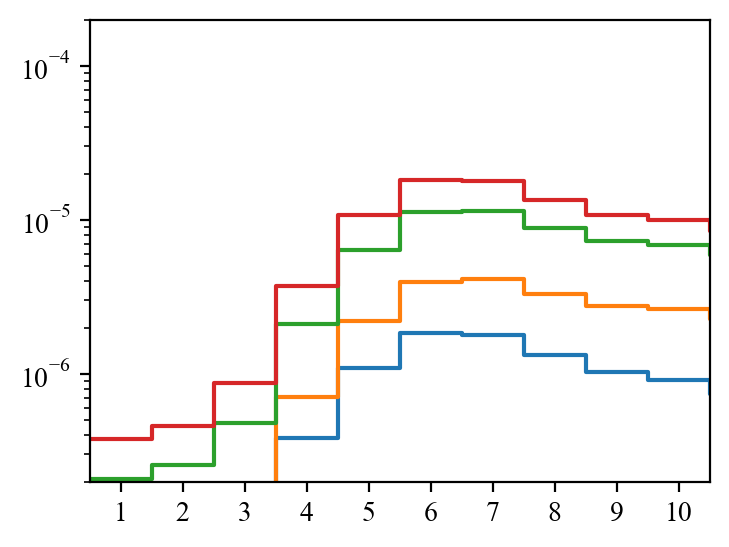

In [15]:
b1 = np.loadtxt('../data/binned_signal_w_shield_w_lindhard/binned_signals_mDM=0.01_GeV_sigma=2.40009e-24_cm2.txt')
b2 = np.loadtxt('../data/binned_signal_w_shield_w_lindhard/binned_signals_mDM=0.1_GeV_sigma=2.84519e-23_cm2.txt')
b3 = np.loadtxt('../data/binned_signal_w_shield_w_lindhard/binned_signals_mDM=1_GeV_sigma=4.12016e-22_cm2.txt')
b4 = np.loadtxt('../data/binned_signal_w_shield_w_lindhard/binned_signals_mDM=10_GeV_sigma=4.94e-21_cm2.txt')
exposure = 3574.278 * 244 / 245
b1 = b1 / exposure
b2 = b2 / exposure
b3 = b3 / exposure
b4 = b4 / exposure
N_bin = 30
bins = np.arange(0.5,N_bin+0.5,1)
fig, ax = plt.subplots(figsize=(4, 3),dpi = 200)
fontsize = 12
ax.semilogy(bins, b1, drawstyle='steps-post')
ax.semilogy(bins, b2, drawstyle='steps-post')
ax.semilogy(bins, b3, drawstyle='steps-post')
ax.semilogy(bins, b4, drawstyle='steps-post')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_ylim(2e-7,2e-4)
ax.set_xlim(0.5, 10.5)